problem statement

In recent years, city hotel and resort have seen high cancellation rates. Each hotel is now dealing with a number of issues as a result, including fewer revenue and less than ideal hotel room use. Consequently, lowering cancellation rates is both hotels primary goal in order to increase their efficiency in generating revenue for us through bussiness advice according to problems.

the analysis of hotel booking cancelliation as well as other factors that have no bearing on their bussiness and yearly revenue are the main topic of this resort and hotels.

Assumptions
1- No unusual occurances between 2015 and 2017 will have a substantial impact on the  data used.
2- The information is still current and can be used to analyze a hotel's possible plans in an efficient manner.
3- There are no unanticipated negatives to the hotel employing any advasied technique.
4- The hotels are not currently using any of the suggested solutions
5- The biggest factor affecting the affectiveness of earning income is booking cancellations.
6- Cancelliations result in vacent rooms for the booked length of time.
7- clients make hotel reservations the same year they make cancelliation.

Research Questions
1- What the variables that affect hotel reservation cancelliations?
2- How can we make hotel reservations cancelliation better? 
3- How will hotels be assisted in making pricing and promotional decisions?

In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 

import warnings
warnings.filterwarnings('ignore')

In [2]:
df= pd.read_csv('hotel_bookings.csv')
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,1/7/2015
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,1/7/2015
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2/7/2015
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2/7/2015
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,3/7/2015


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

In [4]:
df.shape

(119390, 32)

In [5]:
df.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='str')

In [6]:
df.isnull().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

In [7]:
df['reservation_status_date']= pd.to_datetime(df['reservation_status_date'], dayfirst= True)

In [8]:
df.describe(include=object)

,hotel,arrival_date_month,meal,country,market_segment,distribution_channel,reserved_room_type,assigned_room_type,deposit_type,customer_type,reservation_status
count,119390,119390,119390,118902,119390,119390,119390,119390,119390,119390,119390
unique,2,12,5,177,8,5,10,12,3,4,3
top,City Hotel,August,BB,PRT,Online TA,TA/TO,A,A,No Deposit,Transient,Check-Out
freq,79330,13877,92310,48590,56477,97870,85994,74053,104641,89613,75166


In [9]:
for col in df.describe(include=object):
    print(col)
    print(df[col].unique())
    print("-"* 30)

hotel
<StringArray>
['Resort Hotel', 'City Hotel']
Length: 2, dtype: str
------------------------------
arrival_date_month
<StringArray>
[     'July',    'August', 'September',   'October',  'November',  'December',
   'January',  'February',     'March',     'April',       'May',      'June']
Length: 12, dtype: str
------------------------------
meal
<StringArray>
['BB', 'FB', 'HB', 'SC', 'Undefined']
Length: 5, dtype: str
------------------------------
country
<StringArray>
['PRT', 'GBR', 'USA', 'ESP', 'IRL', 'FRA',   nan, 'ROU', 'NOR', 'OMN',
 ...
 'ATA', 'GTM', 'ASM', 'MRT', 'NCL', 'KIR', 'SDN', 'ATF', 'SLE', 'LAO']
Length: 178, dtype: str
------------------------------
market_segment
<StringArray>
[       'Direct',     'Corporate',     'Online TA', 'Offline TA/TO',
 'Complementary',        'Groups',     'Undefined',      'Aviation']
Length: 8, dtype: str
------------------------------
distribution_channel
<StringArray>
['Direct', 'Corporate', 'TA/TO', 'Undefined', 'GDS']
Length: 5

In [10]:
df.drop(['agent', 'company'], axis= 1, inplace=True)

In [11]:
df.dropna(inplace=True)

In [12]:
df.isnull().sum()

hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_year                 0
arrival_date_month                0
arrival_date_week_number          0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
meal                              0
country                           0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
assigned_room_type                0
booking_changes                   0
deposit_type                      0
days_in_waiting_list              0
customer_type                     0
adr                               0
required_car_parking_spaces       0
total_of_special_requests   

In [13]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests,reservation_status_date
count,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898
mean,0.371352,104.311435,2016.157656,27.166555,15.800880,0.928897,2.502145,1.858391,0.104207,0.007948,0.032011,0.087142,0.131634,0.221181,2.330754,102.003243,0.061885,0.571683,2016-07-30 07:37:53.336809
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-6.380000,0.000000,0.000000,2014-10-17 00:00:00
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,70.000000,0.000000,0.000000,2016-02-02 00:00:00
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,95.000000,0.000000,0.000000,2016-08-08 00:00:00
75%,1.000000,161.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,126.000000,0.000000,1.000000,2017-02-09 00:00:00
max,1.000000,737.000000,2017.000000,53.000000,31.000000,16.000000,41.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,391.000000,5400.000000,8.000000,5.000000,2017-09-14 00:00:00
std,0.483168,106.903309,0.707459,13.589971,8.780324,0.996216,1.900168,0.578576,0.399172,0.097380,0.176029,0.845869,1.484672,0.652785,17.630452,50.485862,0.244172,0.792678,NaN


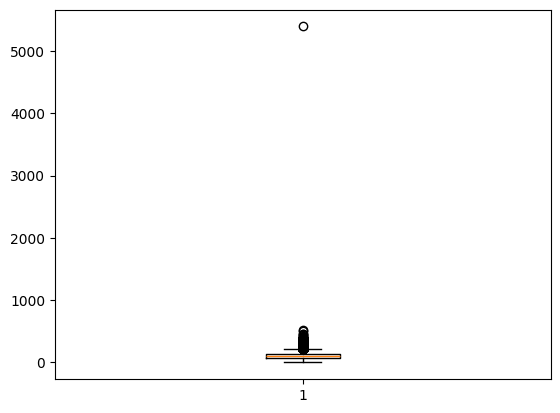

In [14]:
plt.boxplot(df['adr'])
plt.show()

In [15]:
Q1 = df['adr'].quantile(0.25)
Q3 = df['adr'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df['adr'] >= lower) & (df['adr'] <= upper)]

In [16]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests,reservation_status_date
count,115015.000000,115015.000000,115015.000000,115015.000000,115015.000000,115015.000000,115015.000000,115015.000000,115015.000000,115015.000000,115015.000000,115015.000000,115015.000000,115015.000000,115015.000000,115015.000000,115015.000000,115015.000000,115015
mean,0.370795,105.368326,2016.146051,27.045220,15.775247,0.921845,2.482720,1.847794,0.082607,0.007486,0.032639,0.089893,0.135348,0.216893,2.399722,97.107161,0.058949,0.561562,2016-07-24 22:01:41.099856
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-6.380000,0.000000,0.000000,2014-10-17 00:00:00
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,68.000000,0.000000,0.000000,2016-01-28 00:00:00
50%,0.000000,70.000000,2016.000000,27.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,92.400000,0.000000,0.000000,2016-07-31 00:00:00
75%,1.000000,163.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,121.370000,0.000000,1.000000,2017-02-02 00:00:00
max,1.000000,737.000000,2017.000000,53.000000,31.000000,16.000000,41.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,391.000000,210.000000,8.000000,5.000000,2017-09-14 00:00:00
std,0.483020,107.759534,0.706932,13.741209,8.783105,0.995165,1.897364,0.578715,0.349738,0.095025,0.177691,0.859784,1.508844,0.647480,17.908152,40.421284,0.238793,0.784797,NaN


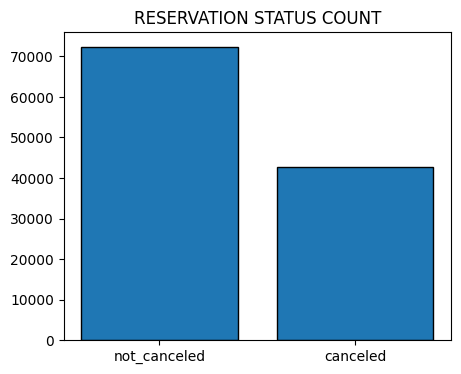

In [73]:
canceled_percnt= df['is_canceled'].value_counts(normalize=True)*100
canceled_percnt
plt.figure(figsize=(5,4))
plt.title('RESERVATION STATUS COUNT')
plt.bar(['not_canceled', 'canceled'], df['is_canceled'].value_counts(), edgecolor="black")
plt.savefig('reservation_count')
plt.show()

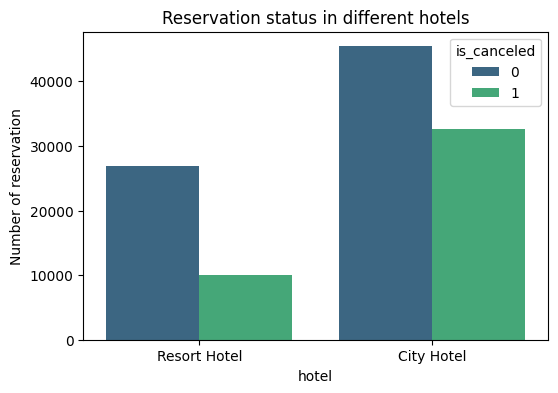

In [74]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="hotel", hue="is_canceled", palette="viridis")
#legend_labels,_= ax1.get_legend_handles_labels()
#ax1.legend(bbox_to_anchor(1,1))
plt.title('Reservation status in different hotels')
plt.ylabel('Number of reservation')
plt.savefig('reservation_hotels')
plt.show()

In [19]:
resort_hotel= df[df['hotel']== 'Resort Hotel'] 
resort_hotel['is_canceled'].value_counts(normalize= True)

is_canceled
0    0.727997
1    0.272003
Name: proportion, dtype: float64

In [20]:
city_hotel= df[df['hotel']== 'City Hotel'] 
city_hotel['is_canceled'].value_counts(normalize= True)


is_canceled
0    0.582297
1    0.417703
Name: proportion, dtype: float64

In [21]:
resort_hotel= resort_hotel.groupby('reservation_status_date')[['adr']].mean()
city_hotel=city_hotel.groupby('reservation_status_date')[['adr']].mean()

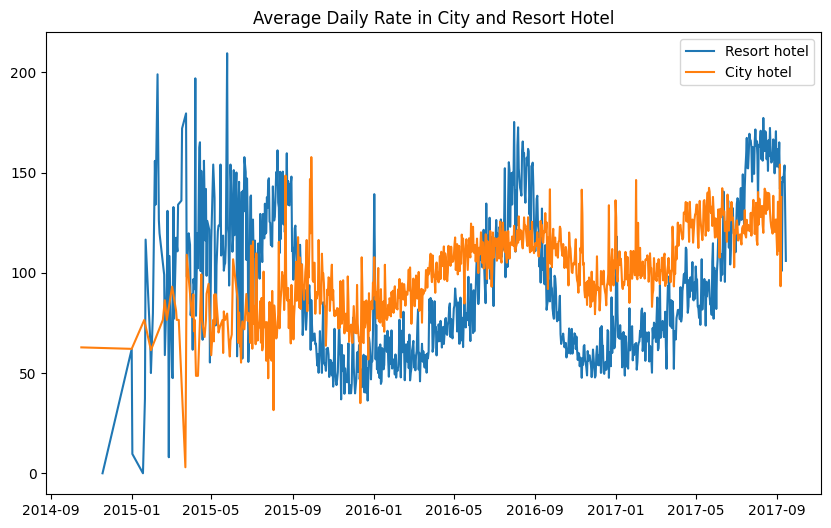

In [75]:
plt.figure(figsize=(10,6))
plt.plot(resort_hotel.index, resort_hotel['adr'], label='Resort hotel')

plt.plot(city_hotel.index, city_hotel['adr'], label='City hotel')
plt.title('Average Daily Rate in City and Resort Hotel')
plt.legend()
plt.savefig('average_daily_rates')
plt.show()

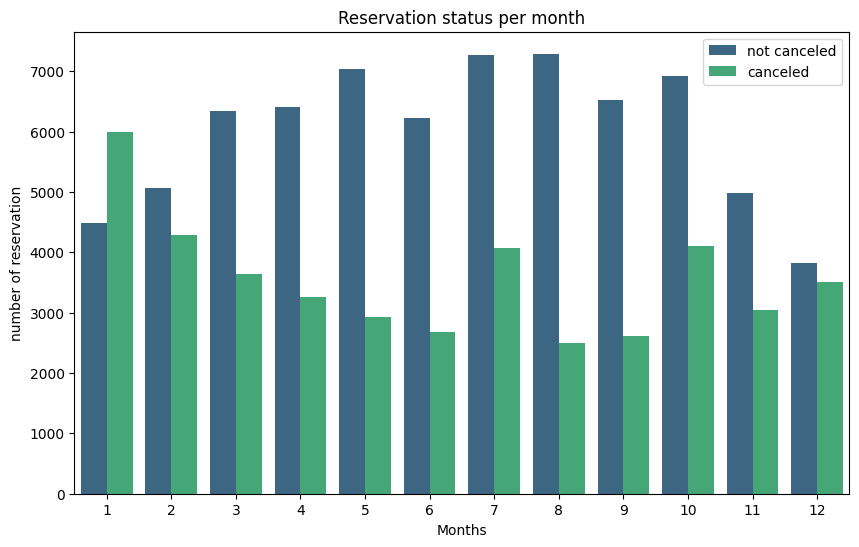

In [76]:
df['month']=df['reservation_status_date'].dt.month
plt.figure(figsize=(10,6))
sns.countplot(data= df, x='month', hue='is_canceled', palette='viridis')
plt.title('Reservation status per month')
plt.xlabel('Months')
plt.ylabel("number of reservation")
plt.legend(['not canceled','canceled'])
plt.savefig('reservation_per_month')
plt.show()

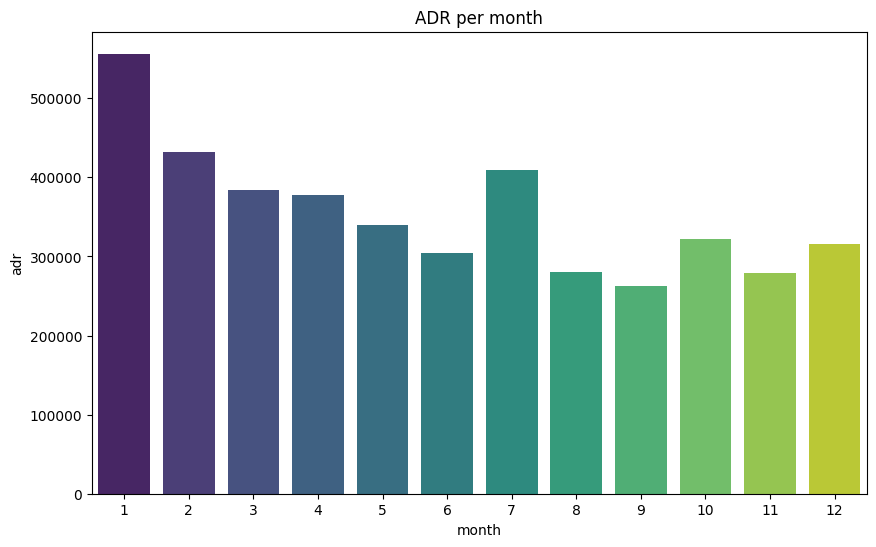

In [77]:
plt.figure(figsize=(10,6))
sns.barplot(x='month',y='adr',data= df[df['is_canceled']== 1].groupby('month')[['adr']].sum().reset_index(), palette='viridis')
plt.title('ADR per month')
plt.savefig('adr_per_month')
plt.show()

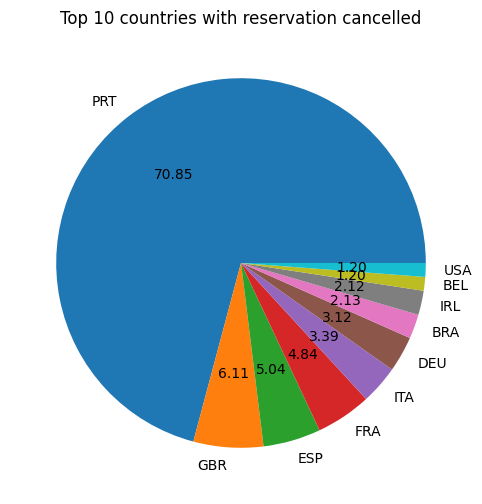

In [78]:
cancelled_data = df[df['is_canceled'] == 1]
top_10_country = cancelled_data['country'].value_counts()[:10]
plt.figure(figsize=(10,6))
plt.pie(top_10_country, autopct='%.2f', labels=top_10_country.index)
plt.title('Top 10 countries with reservation cancelled')
plt.savefig('top_10_counrty_resv_cancel')
plt.show()

In [28]:
df['market_segment'].value_counts(normalize=True)

market_segment
Online TA        0.466357
Offline TA/TO    0.209121
Groups           0.171360
Direct           0.100343
Corporate        0.044377
Complementary    0.006382
Aviation         0.002061
Name: proportion, dtype: float64

In [30]:
cancelled_data['market_segment'].value_counts(normalize=True)

market_segment
Online TA        0.456679
Groups           0.282763
Offline TA/TO    0.193636
Direct           0.040706
Corporate        0.022886
Complementary    0.002110
Aviation         0.001219
Name: proportion, dtype: float64

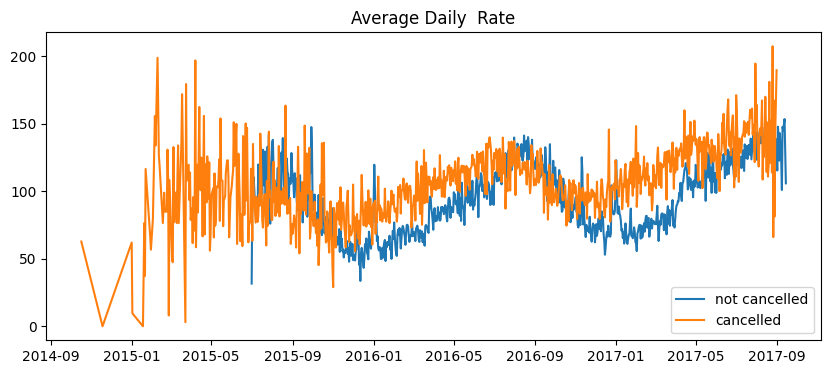

In [53]:
cancelled_df_adr = cancelled_data.groupby('reservation_status_date')[['adr']].mean()
cancelled_df_adr.reset_index(inplace=True)
cancelled_df_adr.sort_values('reservation_status_date', inplace=True)

not_cancelled_data= df[df['is_canceled']== 0]
not_cancelled_df_adr= not_cancelled_data.groupby('reservation_status_date')[['adr']].mean()
not_cancelled_df_adr.reset_index(inplace=True)
not_cancelled_df_adr.sort_values('reservation_status_date', inplace=True)

plt.figure(figsize=(10,4))
plt.plot(not_cancelled_df_adr['reservation_status_date'], not_cancelled_df_adr['adr'], label='not cancelled')
plt.plot(cancelled_df_adr['reservation_status_date'], cancelled_df_adr['adr'], label='cancelled')
plt.legend()
plt.title('Average Daily  Rate')
plt.show()

In [67]:
cancelled_df_adr = cancelled_df_adr[(cancelled_df_adr['reservation_status_date']> '2016') & (cancelled_df_adr['reservation_status_date']< '2017- 09')] 
not_cancelled_df_adr= not_cancelled_df_adr[(not_cancelled_df_adr['reservation_status_date']> '2016') & (not_cancelled_df_adr['reservation_status_date']< '2017-09')]

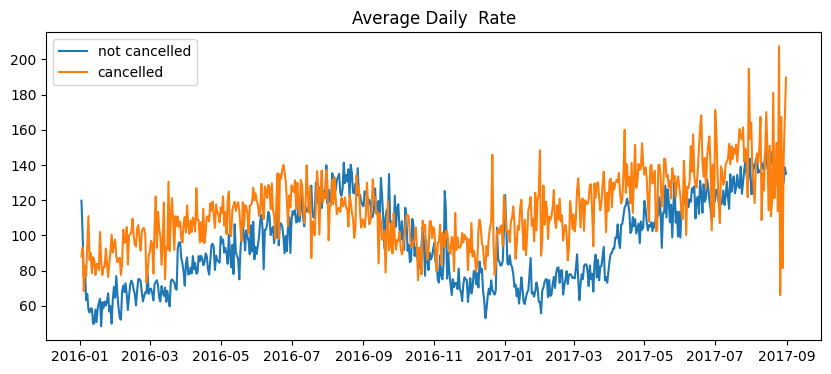

In [79]:
plt.figure(figsize=(10,4))
plt.plot(not_cancelled_df_adr['reservation_status_date'], not_cancelled_df_adr['adr'], label='not cancelled')
plt.plot(cancelled_df_adr['reservation_status_date'], cancelled_df_adr['adr'], label='cancelled')
plt.legend()
plt.title('Average Daily  Rate')
plt.savefig('average_daily_rates_2016-17')
plt.show()